In [1]:
# Code adapted from Machine Learning Engineering (Cornell Tech 2025)
import torch
import numpy as np
import random

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [2]:
from google.colab import drive
import sys
import os

# --- 1. Mount Drive ---
drive.mount('/content/drive')

# --- 2. Define Paths ---
# Path to the source code (loaders.py) - REMAINS ON DRIVE
DRIVE_CODE_PATH = '/content/drive/MyDrive/GoogleColab/dataforsptransformer/'

# Path to the zipped data file on Drive
ZIP_SOURCE_PATH = os.path.join(DRIVE_CODE_PATH, 'crc_markers.zip')

# Local disk folder where the FAST images will be unzipped
FAST_DATA_PATH = '/content/fast_data/'

# --- 3. Unzip Data (Performance Fix) ---
if not os.path.exists(FAST_DATA_PATH):
    print(f"🚀 Unzipping data from Drive to fast local disk: {FAST_DATA_PATH}")
    !mkdir -p "$FAST_DATA_PATH"
    # The -q flag silences the output. -d sets the destination directory.
    !unzip -q "$ZIP_SOURCE_PATH" -d "$FAST_DATA_PATH"

    print("✅ Data transfer complete. Starting new batch load test.")
else:
    print("Fast data directory already exists.")


# --- 4. Set Final Variables ---
# PROJECT_DIR for the rest of your notebook now points to the FAST images
PROJECT_DIR = FAST_DATA_PATH

# Add the Drive path for Python to find 'loaders.py' and other modules
if DRIVE_CODE_PATH not in sys.path:
    sys.path.append(DRIVE_CODE_PATH)
    print(f"✅ Added {DRIVE_CODE_PATH} to Python system path.")

Mounted at /content/drive
🚀 Unzipping data from Drive to fast local disk: /content/fast_data/
✅ Data transfer complete. Starting new batch load test.
✅ Added /content/drive/MyDrive/GoogleColab/dataforsptransformer/ to Python system path.


In [6]:
from google.colab import files

# This will open a 'Choose Files' button in your output cell
# Choose train_helpers.py
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving training.py to training.py
User uploaded file "training.py" with length 19619 bytes


In [7]:
!python3 data_cleaning.py

Computing KNN (k=5) for each graph separately...
Found 140 unique graphs
KNN computation complete! Total cells: 258385

Sample of cleaned data:
               GraphID  CellID  ...  Z:Z                                    KNN
0  reg001_A 1 reg001 1       0  ...   10            [22144, 50530, 3, 98132, 2]
1  reg001_A 1 reg001 1       1  ...   10  [33870, 50531, 118271, 33869, 118273]
2  reg001_A 1 reg001 1       2  ...   10            [3, 98132, 50530, 0, 22144]
3  reg001_A 1 reg001 1       3  ...   10            [50530, 98132, 2, 0, 22144]
4  reg001_A 1 reg001 1       4  ...   10      [118281, 98134, 118276, 5, 98140]

[5 rows x 6 columns]
Number cells: 258385, Number unique CellIDs 258385


In [8]:
import pandas as pd

df = pd.read_csv("/content/fast_data/CRC_clusters_neighborhoods_markers_cleaned.csv")
df.head()

,CellID,CD44 - stroma:Cyc_2_ch_2,FOXP3 - regulatory T cells:Cyc_2_ch_3,CD8 - cytotoxic T cells:Cyc_3_ch_2,p53 - tumor suppressor:Cyc_3_ch_3,GATA3 - Th2 helper T cells:Cyc_3_ch_4,CD45 - hematopoietic cells:Cyc_4_ch_2,T-bet - Th1 cells:Cyc_4_ch_3,beta-catenin - Wnt signaling:Cyc_4_ch_4,HLA-DR - MHC-II:Cyc_5_ch_2,...,CD68+Ki67+,CD68+PD-1+,CD8+ICOS+,CD8+Ki67+,CD8+PD-1+,Treg-ICOS+,Treg-Ki67+,Treg-PD-1+,GraphID,KNN
0,0,1.843591,17.398706,0.000000,59.391884,35.244526,0.000000,45.537239,258.346375,0.000000,...,0,0,0,0,0,0,0,0,reg001_A 1 reg001 1,"[22144, 50530, 3, 98132, 2]"
1,1,30.284525,18.375738,74.695236,271.420136,30.313547,0.000000,8.821254,668.978577,0.000000,...,0,0,0,0,0,0,0,0,reg001_A 1 reg001 1,"[33870, 50531, 118271, 33869, 118273]"
2,2,139.488510,249.746979,85.556976,705.369324,49.865829,8.435891,179.875778,480.811737,3.066591,...,0,0,0,0,0,0,0,0,reg001_A 1 reg001 1,"[3, 98132, 50530, 0, 22144]"
3,3,20.596886,81.759758,0.000000,0.000000,34.731583,0.000000,122.186234,145.830063,0.000000,...,0,0,0,0,0,0,0,0,reg001_A 1 reg001 1,"[50530, 98132, 2, 0, 22144]"
4,4,67.328728,122.195473,11.028284,325.076691,93.776245,0.000000,323.319305,987.071655,0.000000,...,0,0,0,0,0,0,0,0,reg001_A 1 reg001 1,"[118281, 98134, 118276, 5, 98140]"


In [9]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 86.1 MB/s eta 0:00:00


In [10]:
df.columns

Index(['CellID', 'CD44 - stroma:Cyc_2_ch_2',
       'FOXP3 - regulatory T cells:Cyc_2_ch_3',
       'CD8 - cytotoxic T cells:Cyc_3_ch_2',
       'p53 - tumor suppressor:Cyc_3_ch_3',
       'GATA3 - Th2 helper T cells:Cyc_3_ch_4',
       'CD45 - hematopoietic cells:Cyc_4_ch_2', 'T-bet - Th1 cells:Cyc_4_ch_3',
       'beta-catenin - Wnt signaling:Cyc_4_ch_4', 'HLA-DR - MHC-II:Cyc_5_ch_2',
       'PD-L1 - checkpoint:Cyc_5_ch_3', 'Ki67 - proliferation:Cyc_5_ch_4',
       'CD45RA - naive T cells:Cyc_6_ch_2', 'CD4 - T helper cells:Cyc_6_ch_3',
       'CD21 - DCs:Cyc_6_ch_4', 'MUC-1 - epithelia:Cyc_7_ch_2',
       'CD30 - costimulator:Cyc_7_ch_3', 'CD2 - T cells:Cyc_7_ch_4',
       'Vimentin - cytoplasm:Cyc_8_ch_2', 'CD20 - B cells:Cyc_8_ch_3',
       'LAG-3 - checkpoint:Cyc_8_ch_4', 'Na-K-ATPase - membranes:Cyc_9_ch_2',
       'CD5 - T cells:Cyc_9_ch_3', 'IDO-1 - metabolism:Cyc_9_ch_4',
       'Cytokeratin - epithelia:Cyc_10_ch_2',
       'CD11b - macrophages:Cyc_10_ch_3', 'CD56 - NK cells:C

## Setup Training Environment

In [11]:
# Add current directory to path so we can import training.py
import sys
import os
sys.path.append(os.getcwd())

from training import train_graphformer, simple_neighbor_average_baseline

# Start and end protein columns as identified in the notebook
START_PROTEIN = 'CD44 - stroma:Cyc_2_ch_2'
END_PROTEIN = 'CD138 - plasma cells:Cyc_21_ch_3'
protein_cols = df.columns[df.columns.get_loc(START_PROTEIN) : df.columns.get_loc(END_PROTEIN)+1].tolist()

## Level 1 Hyperparameter Optimization

We optimize the core capacity and stability parameters first:
1. **Learning Rate**: Determines convergence speed and stability.
2. **Max Neighbors (k)**: Determines the biological spatial context size.
3. **Number of Layers**: Determines the depth of the graph receptive field.

In [14]:
def run_and_score(params, *, rebuild_KNN=False, test_baseline=False, epochs=5):
    model, _, _ = train_graphformer(
        df,
        protein_start_col=START_PROTEIN,
        protein_end_col=END_PROTEIN,
        normalize=True,
        num_epochs=epochs,
        rebuild_knn=rebuild_KNN,
        test_baseline=test_baseline,
        **params,
    )

    checkpoint = torch.load('best_graphformer_model.pt', weights_only=False)
    return checkpoint['r2']


Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Rebuilding KNN (k=5) relationships within train/test splits...
KNN rebuild complete!

Testing neighbor average baseline...

Neighbor Average Baseline - Best Proteins:
  Granzyme B - cytotoxicity:Cyc_13_ch_2              R²: -0.2004
  CD7 - T cells:Cyc_16_ch_3                          R²: -0.2344
  Chromogranin A - neuroendocrine:Cyc_17_ch_2        R²: -0.2671
  CD31 - vasculature:Cyc_19_ch_3                     R²: -0.2937
  CD8 - cytotoxic T cells:Cyc_3_ch_2                 R²: -0.2948
  FOXP3 - regulatory T cells:Cyc_2_ch_3              R²: -0.3081
  BCL-2 - apoptosis:Cyc_11_ch_3                      R²: -0.3108
  HLA-DR - MHC-II:Cyc_5_ch_2                         R²: -0.3111
  CD15 - granulocytes:Cyc_14_ch_2                    R²: -0.3176
  CD4 - T helper cells:Cyc_6_ch_3                    R²: -0.3237

Neig

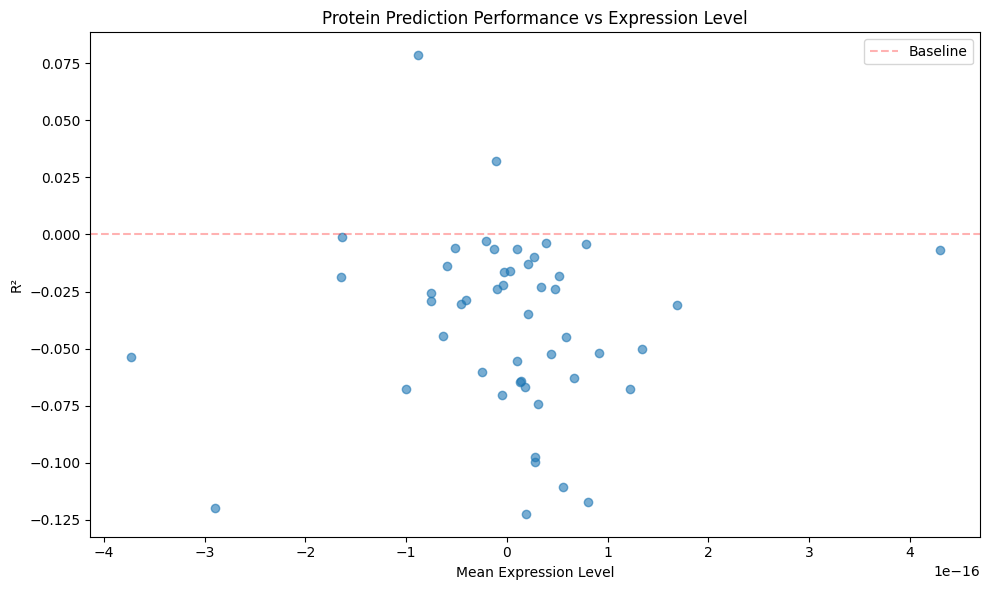


Correlation between mean expression and R²: 0.0102
Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Rebuilding KNN (k=10) relationships within train/test splits...
KNN rebuild complete!
Model parameters: 624,049
Epoch 1/5
  Train Loss: 0.8837
  Test Loss: 1.1301, MAE: 0.15, R²: -0.0255, Mean Protein R²: -0.0370, Pearson r: 0.0239
  Saved best model (R²: -0.0255)
Epoch 2/5
  Train Loss: 0.8248
  Test Loss: 1.1379, MAE: 0.15, R²: -0.0265, Mean Protein R²: -0.0394, Pearson r: 0.0298
Epoch 3/5
  Train Loss: 0.8080
  Test Loss: 1.1377, MAE: 0.15, R²: -0.0268, Mean Protein R²: -0.0393, Pearson r: 0.0324
Epoch 4/5
  Train Loss: 0.7998
  Test Loss: 1.1407, MAE: 0.15, R²: -0.0281, Mean Protein R²: -0.0410, Pearson r: 0.0270
Epoch 5/5
  Train Loss: 0.7957
  Test Loss: 1.1407, MAE: 0.15, R²: -0.0276, Mean Protein R²: -0.0405, Pearson r: 0.0286
Best predicted proteins:

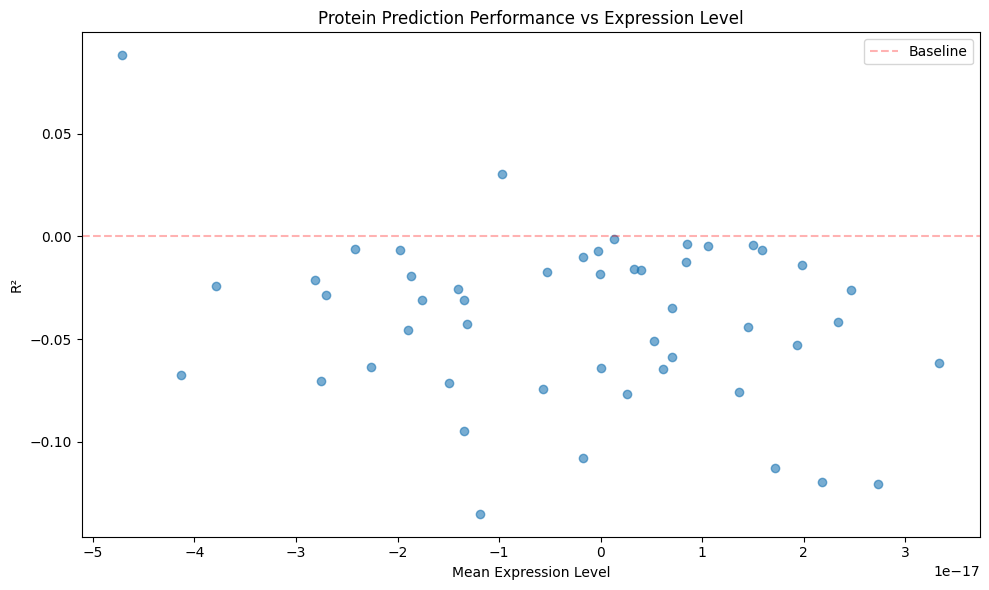


Correlation between mean expression and R²: -0.2565
Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Rebuilding KNN (k=20) relationships within train/test splits...
KNN rebuild complete!
Model parameters: 624,049
Epoch 1/5
  Train Loss: 0.8723
  Test Loss: 1.1402, MAE: 0.15, R²: -0.0280, Mean Protein R²: -0.0410, Pearson r: 0.0302
  Saved best model (R²: -0.0280)
Epoch 2/5
  Train Loss: 0.8139
  Test Loss: 1.1329, MAE: 0.15, R²: -0.0249, Mean Protein R²: -0.0370, Pearson r: 0.0380
  Saved best model (R²: -0.0249)
Epoch 3/5
  Train Loss: 0.7979
  Test Loss: 1.1274, MAE: 0.15, R²: -0.0229, Mean Protein R²: -0.0342, Pearson r: 0.0416
  Saved best model (R²: -0.0229)
Epoch 4/5
  Train Loss: 0.7907
  Test Loss: 1.1307, MAE: 0.15, R²: -0.0247, Mean Protein R²: -0.0366, Pearson r: 0.0354
Epoch 5/5
  Train Loss: 0.7871
  Test Loss: 1.1333, MAE: 0.15, R²: -0.0259, Me

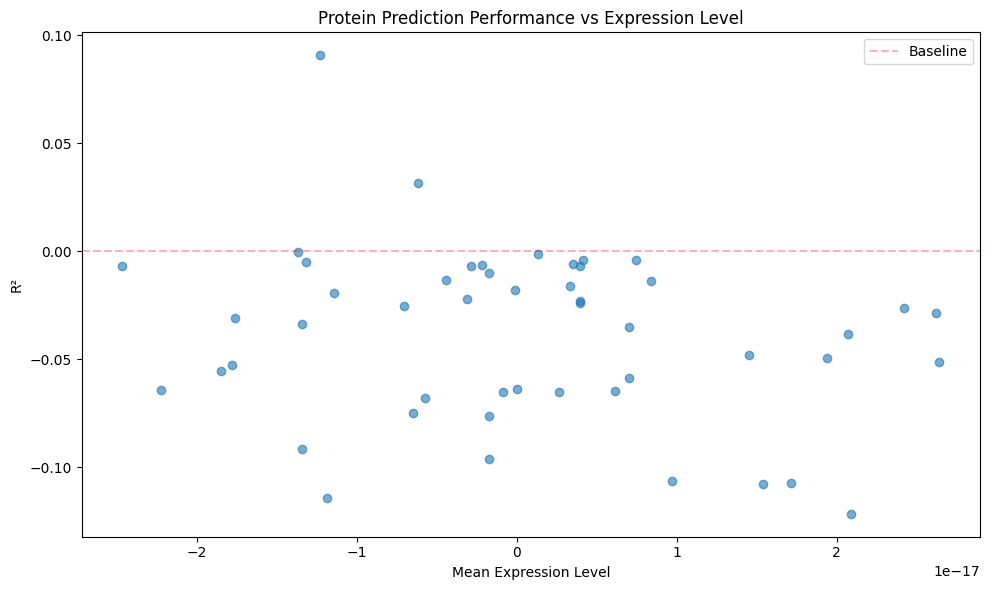


Correlation between mean expression and R²: -0.2145
Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Rebuilding KNN (k=50) relationships within train/test splits...
KNN rebuild complete!
Model parameters: 624,049
Epoch 1/5
  Train Loss: 0.8609
  Test Loss: 1.1362, MAE: 0.15, R²: -0.0272, Mean Protein R²: -0.0402, Pearson r: 0.0287
  Saved best model (R²: -0.0272)
Epoch 2/5
  Train Loss: 0.8043
  Test Loss: 1.1378, MAE: 0.15, R²: -0.0279, Mean Protein R²: -0.0398, Pearson r: 0.0337
Epoch 3/5
  Train Loss: 0.7907
  Test Loss: 1.1307, MAE: 0.15, R²: -0.0265, Mean Protein R²: -0.0390, Pearson r: 0.0380
  Saved best model (R²: -0.0265)
Epoch 4/5
  Train Loss: 0.7839
  Test Loss: 1.1331, MAE: 0.15, R²: -0.0274, Mean Protein R²: -0.0394, Pearson r: 0.0318
Epoch 5/5
  Train Loss: 0.7809
  Test Loss: 1.1359, MAE: 0.15, R²: -0.0291, Mean Protein R²: -0.0416, Pearson 

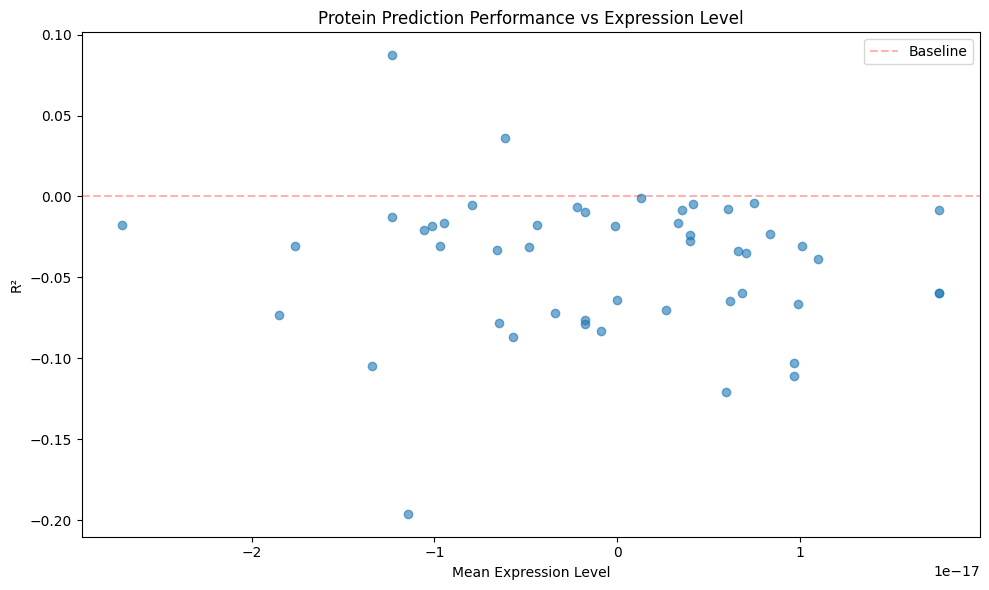


Correlation between mean expression and R²: -0.0805


In [15]:
graph_anchor = dict(max_neighbors=10, num_layers=3)

graph_sweep = [
    dict(max_neighbors=5),
    dict(max_neighbors=10),
    dict(max_neighbors=20),
    dict(max_neighbors=50),
]

best_graph = None
best_r2 = -float("inf")

for i, delta in enumerate(graph_sweep):
    params = {**graph_anchor, **delta}

    r2 = run_and_score(
        params | dict(
            lr=1e-4,
            dropout=0.2,
            l2_reg=1e-4,
            hidden_dim=128,
            num_heads=4,
        ),
        rebuild_KNN=True,
        test_baseline=(i == 0),
    )

    if r2 > best_r2:
        best_r2 = r2
        best_graph = params


Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/5
  Train Loss: 0.9589
  Test Loss: 1.0095, MAE: 0.14, R²: -0.0198, Mean Protein R²: -0.0293, Pearson r: 0.0878
  Saved best model (R²: -0.0198)
Epoch 2/5
  Train Loss: 0.9292
  Test Loss: 0.9812, MAE: 0.14, R²: -0.0041, Mean Protein R²: -0.0110, Pearson r: 0.2281
  Saved best model (R²: -0.0041)
Epoch 3/5
  Train Loss: 0.9143
  Test Loss: 0.9685, MAE: 0.14, R²: 0.0091, Mean Protein R²: 0.0049, Pearson r: 0.2749
  Saved best model (R²: 0.0091)
Epoch 4/5
  Train Loss: 0.9050
  Test Loss: 0.9602, MAE: 0.14, R²: 0.0192, Mean Protein R²: 0.0167, Pearson r: 0.3001
  Saved best model (R²: 0.0192)
Epoch 5/5
  Train Loss: 0.9011
  Test Loss: 0.9575, MAE: 0.14, R²: 0.0220, Mean Protein R²: 0.0203, Pearson r: 0.3047
  Saved best model (R²: 0.0220)
Best predicted proteins:
Protein       

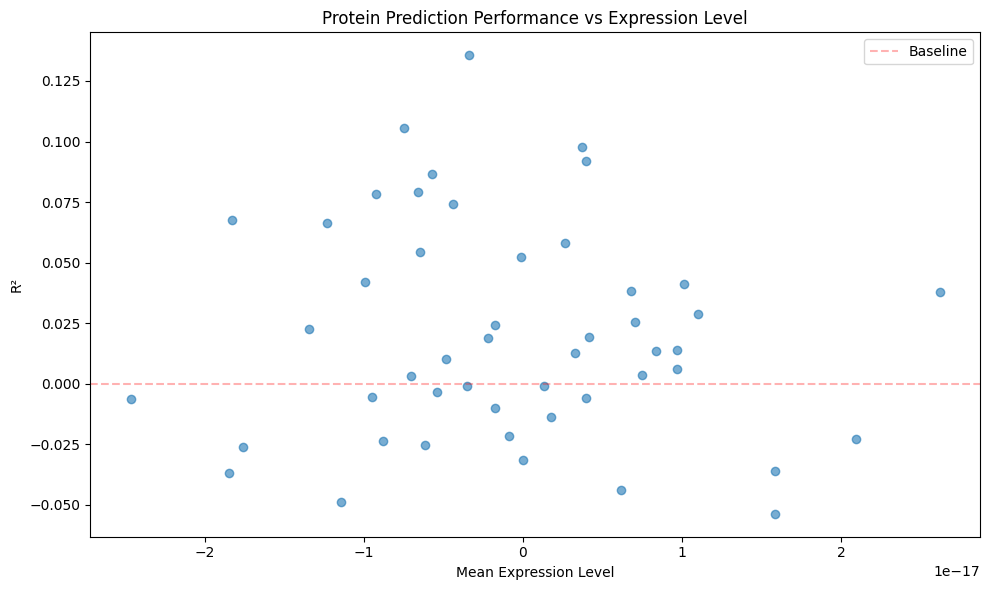


Correlation between mean expression and R²: -0.0973
Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/5
  Train Loss: 0.8728
  Test Loss: 0.8420, MAE: 0.13, R²: 0.1557, Mean Protein R²: 0.1785, Pearson r: 0.4323
  Saved best model (R²: 0.1557)
Epoch 2/5
  Train Loss: 0.7871
  Test Loss: 0.7437, MAE: 0.11, R²: 0.2446, Mean Protein R²: 0.2844, Pearson r: 0.5186
  Saved best model (R²: 0.2446)
Epoch 3/5
  Train Loss: 0.7512
  Test Loss: 0.6885, MAE: 0.10, R²: 0.2909, Mean Protein R²: 0.3388, Pearson r: 0.5612
  Saved best model (R²: 0.2909)
Epoch 4/5
  Train Loss: 0.7342
  Test Loss: 0.6612, MAE: 0.10, R²: 0.3125, Mean Protein R²: 0.3662, Pearson r: 0.5808
  Saved best model (R²: 0.3125)
Epoch 5/5
  Train Loss: 0.7266
  Test Loss: 0.6597, MAE: 0.10, R²: 0.3154, Mean Protein R²: 0.3684, Pearson r: 0.5824
  Saved best model (R²: 

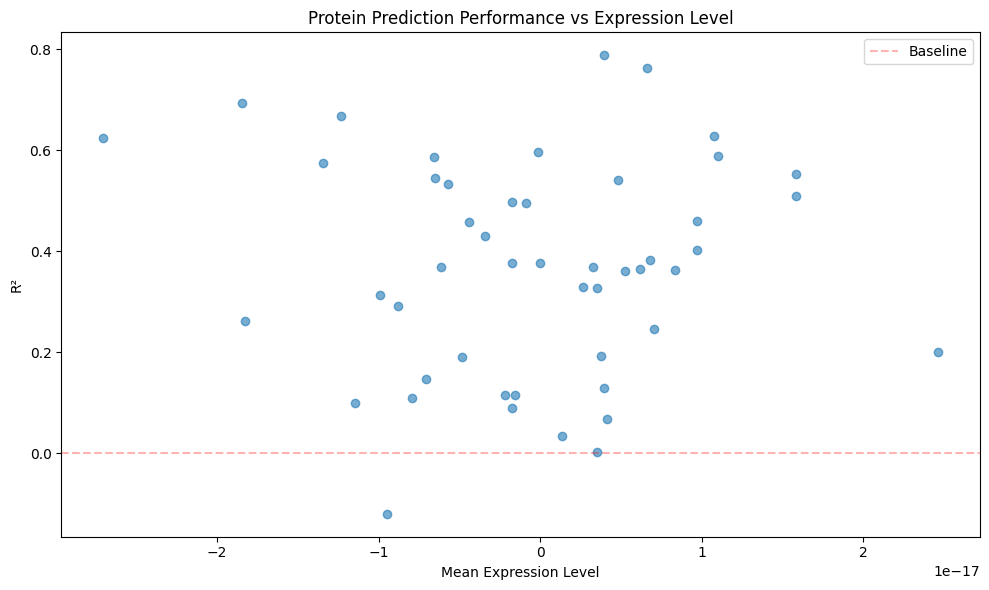


Correlation between mean expression and R²: -0.0027
Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/5
  Train Loss: 0.8949
  Test Loss: 0.8602, MAE: 0.13, R²: 0.1358, Mean Protein R²: 0.1564, Pearson r: 0.4171
  Saved best model (R²: 0.1358)
Epoch 2/5
  Train Loss: 0.8216
  Test Loss: 0.7885, MAE: 0.12, R²: 0.2002, Mean Protein R²: 0.2300, Pearson r: 0.4892
  Saved best model (R²: 0.2002)
Epoch 3/5
  Train Loss: 0.7923
  Test Loss: 0.7601, MAE: 0.12, R²: 0.2338, Mean Protein R²: 0.2615, Pearson r: 0.5136
  Saved best model (R²: 0.2338)
Epoch 4/5
  Train Loss: 0.7784
  Test Loss: 0.7290, MAE: 0.11, R²: 0.2535, Mean Protein R²: 0.2882, Pearson r: 0.5378
  Saved best model (R²: 0.2535)
Epoch 5/5
  Train Loss: 0.7710
  Test Loss: 0.7238, MAE: 0.11, R²: 0.2566, Mean Protein R²: 0.2935, Pearson r: 0.5392
  Saved best model (R²: 0

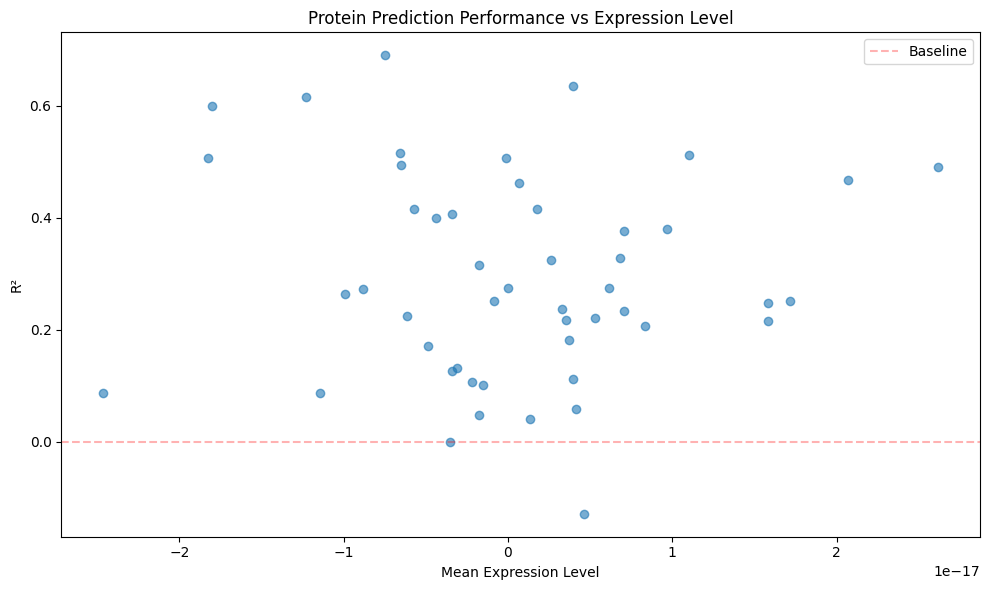


Correlation between mean expression and R²: -0.0360
Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/5
  Train Loss: 0.8779
  Test Loss: 0.8145, MAE: 0.12, R²: 0.1765, Mean Protein R²: 0.2048, Pearson r: 0.4665
  Saved best model (R²: 0.1765)
Epoch 2/5
  Train Loss: 0.7915
  Test Loss: 0.7263, MAE: 0.11, R²: 0.2545, Mean Protein R²: 0.2940, Pearson r: 0.5349
  Saved best model (R²: 0.2545)
Epoch 3/5
  Train Loss: 0.7575
  Test Loss: 0.6780, MAE: 0.10, R²: 0.2959, Mean Protein R²: 0.3425, Pearson r: 0.5751
  Saved best model (R²: 0.2959)
Epoch 4/5
  Train Loss: 0.7413
  Test Loss: 0.6594, MAE: 0.10, R²: 0.3147, Mean Protein R²: 0.3636, Pearson r: 0.5833
  Saved best model (R²: 0.3147)
Epoch 5/5
  Train Loss: 0.7347
  Test Loss: 0.6504, MAE: 0.10, R²: 0.3197, Mean Protein R²: 0.3709, Pearson r: 0.5896
  Saved best model (R²: 0

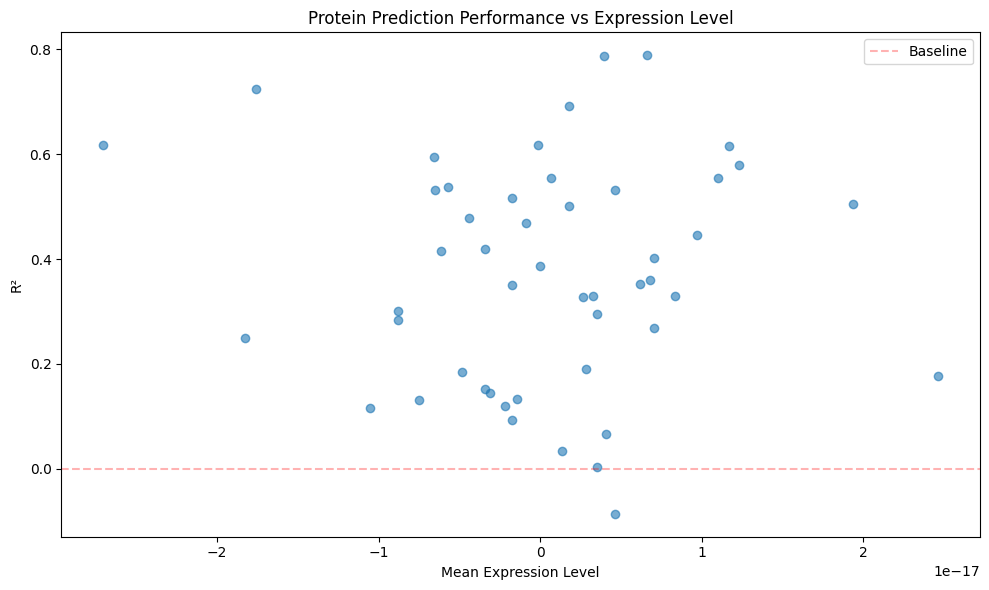


Correlation between mean expression and R²: -0.0106


In [16]:
opt_anchor = dict(lr=1e-4, dropout=0.2, l2_reg=1e-4)

opt_sweep = [
    dict(lr=1e-5),
    dict(dropout=0.1),
    dict(dropout=0.3),
    dict(l2_reg=0),
]

best_opt = opt_anchor
best_r2 = -float("inf")

for delta in opt_sweep:
    params = {**opt_anchor, **delta}

    r2 = run_and_score(
        params | best_graph | dict(hidden_dim=128, num_heads=4),
        rebuild_KNN=False,
        test_baseline=False,
    )

    if r2 > best_r2:
        best_r2 = r2
        best_opt = params


Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 160,497
Epoch 1/5
  Train Loss: 0.9202
  Test Loss: 0.9178, MAE: 0.13, R²: 0.0812, Mean Protein R²: 0.0936, Pearson r: 0.3426
  Saved best model (R²: 0.0812)
Epoch 2/5
  Train Loss: 0.8583
  Test Loss: 0.8663, MAE: 0.13, R²: 0.1344, Mean Protein R²: 0.1557, Pearson r: 0.4067
  Saved best model (R²: 0.1344)
Epoch 3/5
  Train Loss: 0.8318
  Test Loss: 0.8402, MAE: 0.13, R²: 0.1617, Mean Protein R²: 0.1851, Pearson r: 0.4386
  Saved best model (R²: 0.1617)
Epoch 4/5
  Train Loss: 0.8189
  Test Loss: 0.8281, MAE: 0.12, R²: 0.1714, Mean Protein R²: 0.1976, Pearson r: 0.4484
  Saved best model (R²: 0.1714)
Epoch 5/5
  Train Loss: 0.8133
  Test Loss: 0.8238, MAE: 0.12, R²: 0.1756, Mean Protein R²: 0.2023, Pearson r: 0.4522
  Saved best model (R²: 0.1756)
Best predicted proteins:
Protein              

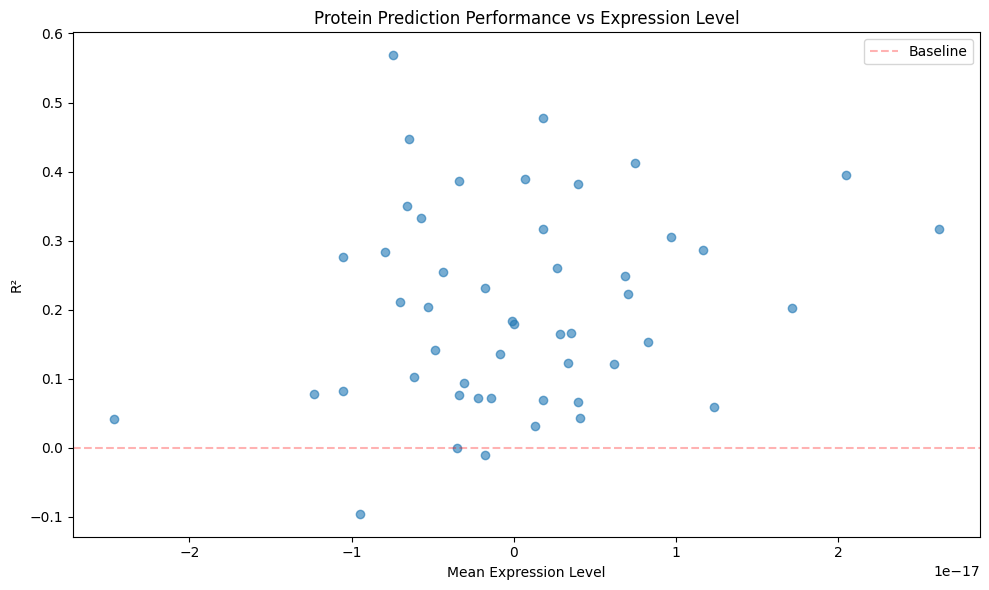


Correlation between mean expression and R²: 0.2032
Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 2,460,465
Epoch 1/5
  Train Loss: 0.8200
  Test Loss: 0.6587, MAE: 0.09, R²: 0.3216, Mean Protein R²: 0.3702, Pearson r: 0.5865
  Saved best model (R²: 0.3216)
Epoch 2/5
  Train Loss: 0.7212
  Test Loss: 0.5836, MAE: 0.08, R²: 0.3843, Mean Protein R²: 0.4479, Pearson r: 0.6326
  Saved best model (R²: 0.3843)
Epoch 3/5
  Train Loss: 0.6888
  Test Loss: 0.5677, MAE: 0.08, R²: 0.4033, Mean Protein R²: 0.4650, Pearson r: 0.6470
  Saved best model (R²: 0.4033)
Epoch 4/5
  Train Loss: 0.6713
  Test Loss: 0.5479, MAE: 0.07, R²: 0.4183, Mean Protein R²: 0.4858, Pearson r: 0.6594
  Saved best model (R²: 0.4183)
Epoch 5/5
  Train Loss: 0.6622
  Test Loss: 0.5422, MAE: 0.07, R²: 0.4247, Mean Protein R²: 0.4922, Pearson r: 0.6642
  Saved best model (R²:

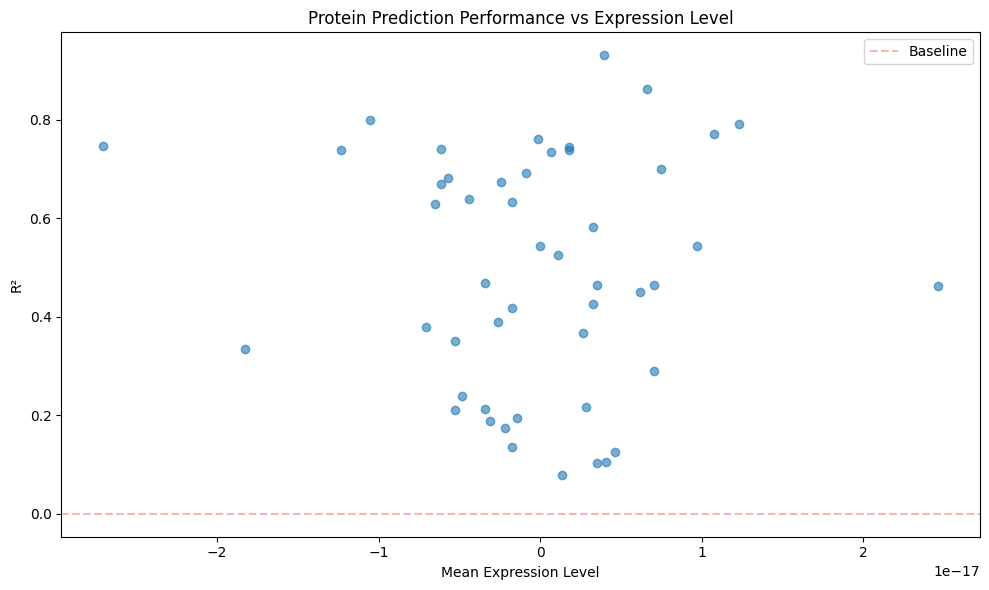


Correlation between mean expression and R²: -0.0332
Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/5
  Train Loss: 0.8739
  Test Loss: 0.8147, MAE: 0.12, R²: 0.1787, Mean Protein R²: 0.2061, Pearson r: 0.4667
  Saved best model (R²: 0.1787)
Epoch 2/5
  Train Loss: 0.7908
  Test Loss: 0.7236, MAE: 0.11, R²: 0.2593, Mean Protein R²: 0.2991, Pearson r: 0.5358
  Saved best model (R²: 0.2593)
Epoch 3/5
  Train Loss: 0.7582
  Test Loss: 0.6855, MAE: 0.10, R²: 0.2921, Mean Protein R²: 0.3369, Pearson r: 0.5683
  Saved best model (R²: 0.2921)
Epoch 4/5
  Train Loss: 0.7421
  Test Loss: 0.6710, MAE: 0.10, R²: 0.3048, Mean Protein R²: 0.3516, Pearson r: 0.5806
  Saved best model (R²: 0.3048)
Epoch 5/5
  Train Loss: 0.7344
  Test Loss: 0.6632, MAE: 0.10, R²: 0.3122, Mean Protein R²: 0.3599, Pearson r: 0.5838
  Saved best model (R²: 

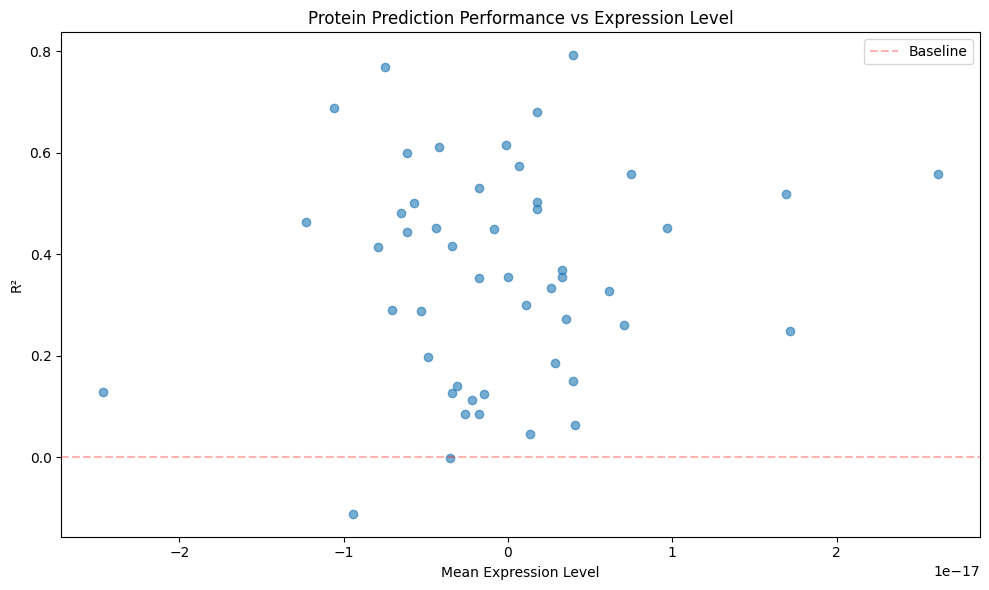


Correlation between mean expression and R²: 0.1207
Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/5
  Train Loss: 0.8791
  Test Loss: 0.8443, MAE: 0.13, R²: 0.1593, Mean Protein R²: 0.1887, Pearson r: 0.4360
  Saved best model (R²: 0.1593)
Epoch 2/5
  Train Loss: 0.7969
  Test Loss: 0.7640, MAE: 0.11, R²: 0.2390, Mean Protein R²: 0.2741, Pearson r: 0.5131
  Saved best model (R²: 0.2390)
Epoch 3/5
  Train Loss: 0.7636
  Test Loss: 0.7027, MAE: 0.11, R²: 0.2789, Mean Protein R²: 0.3222, Pearson r: 0.5554
  Saved best model (R²: 0.2789)
Epoch 4/5
  Train Loss: 0.7465
  Test Loss: 0.6806, MAE: 0.10, R²: 0.2973, Mean Protein R²: 0.3446, Pearson r: 0.5692
  Saved best model (R²: 0.2973)
Epoch 5/5
  Train Loss: 0.7383
  Test Loss: 0.6742, MAE: 0.10, R²: 0.3051, Mean Protein R²: 0.3529, Pearson r: 0.5742
  Saved best model (R²: 0

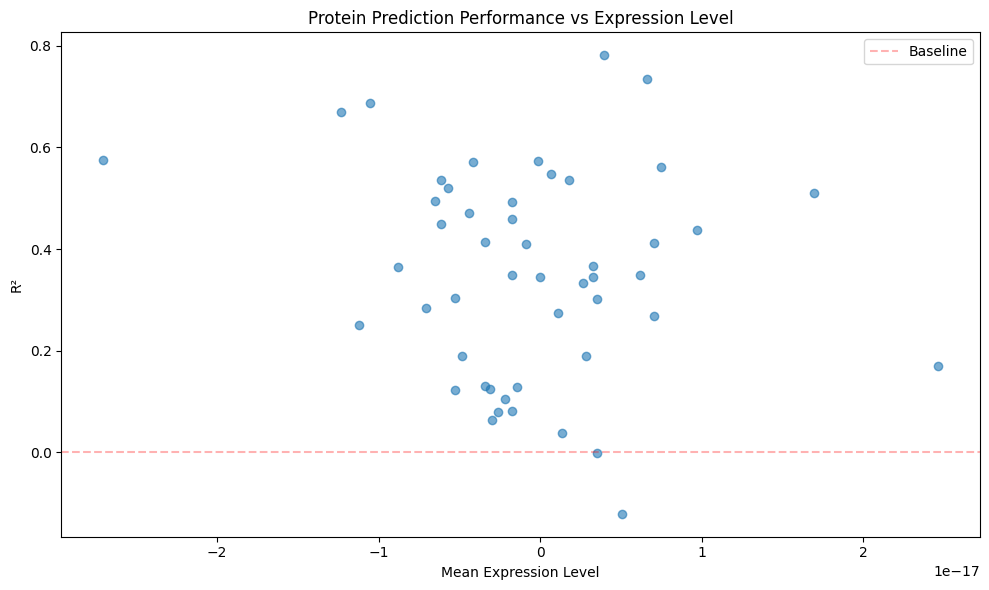


Correlation between mean expression and R²: -0.1409


In [17]:
capacity_anchor = dict(hidden_dim=128, num_heads=4)

capacity_sweep = [
    dict(hidden_dim=64),
    dict(hidden_dim=256),
    dict(num_heads=2),
    dict(num_heads=8),
]

best_cap = capacity_anchor
best_r2 = -float("inf")

for delta in capacity_sweep:
    params = {**capacity_anchor, **delta}

    r2 = run_and_score(
        best_graph | best_opt | params,
        rebuild_KNN=False,
        test_baseline=False,
    )

    if r2 > best_r2:
        best_r2 = r2
        best_cap = params


In [18]:
best_config = best_graph | best_opt | best_cap
print("Best config:", best_config)


Best config: {'max_neighbors': 20, 'num_layers': 3, 'lr': 0.0001, 'dropout': 0.2, 'l2_reg': 0, 'hidden_dim': 256, 'num_heads': 4}


In [ ]:
FINAL_EPOCHS = 20

final_params = {
    **best_graph,
    **best_opt,
    **best_cap,
}

print("Training final model with params:")
print(final_params)

model, train_ds, test_ds = train_graphformer(
    df,
    protein_start_col=START_PROTEIN,
    protein_end_col=END_PROTEIN,
    normalize=True,
    num_epochs=FINAL_EPOCHS,

    # IMPORTANT
    rebuild_KNN=True,        # ensure correct graph
    test_baseline=True,     # already tested

    **final_params,
)
